# Baselines sur le nouveau dataset : Imagewoof

Ce notebook reprend exactement le protocole du notebook `03_run_baselines.ipynb` (HF / BF / MIXTE) mais sur le nouveau dataset **Imagewoof** préparé par le notebook `07_Prepare_New_Dataset.ipynb`.

L'objectif est de vérifier que les conclusions tirées sur Animals-10 se généralisent à un autre jeu de données multi-fidélité.

## Extraire le fichier Zip (Imagewoof) sur le SSD rapide

In [5]:
import zipfile
import time
import os
import shutil
from google.colab import drive

# 1. On branche le Drive
drive.mount('/content/drive', force_remount=True)

# ⚠️ Seule différence avec 03_run_baselines.ipynb : on pointe vers le ZIP Imagewoof
zip_source = "/content/drive/MyDrive/UTBM_PF22/datasets/Imagewoof/dataset_multifidelity.zip"
local_dest = "/content/processed_multifidelity"

# 2. On prépare les données sur le SSD local
# (On force la ré-extraction pour être certain qu'on travaille sur Imagewoof, pas sur les restes d'Animals-10)
if os.path.exists(local_dest):
    print("🧹 Nettoyage des anciennes données (Animals-10) présentes sur le SSD...")
    shutil.rmtree(local_dest)

print("⏳ Copie et extraction du Dataset Imagewoof sur le SSD...")
start = time.time()
shutil.copy2(zip_source, "/content/dataset.zip")

with zipfile.ZipFile("/content/dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

os.remove("/content/dataset.zip")
print(f"✅ Données Imagewoof prêtes en {(time.time()-start):.2f} secondes !")

# Petit contrôle : on affiche les classes trouvées
classes = sorted(os.listdir(f"{local_dest}/train/HF"))
print(f"📚 {len(classes)} classes détectées : {classes}")

Mounted at /content/drive
🧹 Nettoyage des anciennes données (Animals-10) présentes sur le SSD...
⏳ Copie et extraction du Dataset Imagewoof sur le SSD...
✅ Données Imagewoof prêtes en 3.25 secondes !
📚 10 classes détectées : ['n02086240', 'n02087394', 'n02088364', 'n02089973', 'n02093754', 'n02096294', 'n02099601', 'n02105641', 'n02111889', 'n02115641']


## Test des baselines avec 1 epoch (sanity-check)

In [2]:
import sys
import os
import importlib
import torch

print(f"🔥 Matériel : {'GPU PRO ACTIVÉ' if torch.cuda.is_available() else 'CPU (Erreur)'}")

src_path = "/content/drive/MyDrive/UTBM_PF22/src"

if not os.path.exists(src_path):
    print(f"❌ ERREUR : Le dossier {src_path} est introuvable sur le Drive.")
else:
    fichiers = os.listdir(src_path)
    if "train_baselines.py" not in fichiers:
        print(f"❌ ERREUR : 'train_baselines.py' n'est pas dans le dossier src !")
        print(f"💡 Fichiers trouvés : {fichiers}")
    else:
        # 1. On force le dossier src en priorité numéro 1
        if src_path not in sys.path:
            sys.path.insert(0, src_path)

        # 2. On vide le cache des imports
        importlib.invalidate_caches()

        # 3. Importation
        import train_baselines
        importlib.reload(train_baselines)
        from train_baselines import run_baseline

        try:
            print("\n🏁 DÉMARRAGE DU TEST D'INTÉGRATION (1 Époque) sur IMAGEWOOF...")

            run_baseline(mode="HF", epochs=1)
            run_baseline(mode="BF", epochs=1)
            run_baseline(mode="MIXTE", epochs=1)

            print("\n🎉 SANITY-CHECK RÉUSSI ! Tout fonctionne sur Imagewoof.")

        except Exception as e:
            print(f"❌ ERREUR pendant l'entraînement : {e}")

🔥 Matériel : GPU PRO ACTIVÉ

🏁 DÉMARRAGE DU TEST D'INTÉGRATION (1 Époque) sur IMAGEWOOF...

🚀 DÉMARRAGE BASELINE : HF
🔥 Entraînement en cours sur : cuda
📦 Images d'entraînement : 899
💰 Coût par époque : 8990 CA | Coût total estimé : 8990 CA
Époque 1/1 | Loss: 2.4431
⏱️ Entraînement terminé en 0.08 minutes.

--- RÉSULTATS D'ÉVALUATION ---
📊 Précision Test HF (Propre) : 5.80%
📊 Précision Test BF (Bruité) : 5.73%
📊 Précision Mixte (Moyenne) : 5.76%
💾 Résultats et Modèle sauvegardés dans /content/drive/MyDrive/UTBM_PF22/results

🚀 DÉMARRAGE BASELINE : BF
🔥 Entraînement en cours sur : cuda
📦 Images d'entraînement : 8126
💰 Coût par époque : 8126 CA | Coût total estimé : 8126 CA
Époque 1/1 | Loss: 2.1192
⏱️ Entraînement terminé en 0.14 minutes.

--- RÉSULTATS D'ÉVALUATION ---
📊 Précision Test HF (Propre) : 26.65%
📊 Précision Test BF (Bruité) : 25.45%
📊 Précision Mixte (Moyenne) : 26.05%
💾 Résultats et Modèle sauvegardés dans /content/drive/MyDrive/UTBM_PF22/results

🚀 DÉMARRAGE BASELINE : MIX

## Entraînement complet des baselines (20 epochs)

In [6]:
import sys
import os
import importlib
import torch
import zipfile
import shutil
import time
from google.colab import drive

print("--- 🛠️ ÉTAPE 1 : RECONNEXION FORCÉE DU DRIVE ---")
drive.mount('/content/drive', force_remount=True)

print("\n--- 📦 ÉTAPE 2 : VÉRIFICATION DES DONNÉES LOCALES (IMAGEWOOF) ---")
zip_source = "/content/drive/MyDrive/UTBM_PF22/datasets/Imagewoof/dataset_multifidelity.zip"
local_dest = "/content/processed_multifidelity"

if not os.path.exists(local_dest):
    print("⏳ Les données ont disparu du SSD (suite à la déconnexion). Re-décompression en cours...")
    start = time.time()
    shutil.copy2(zip_source, "/content/dataset.zip")
    with zipfile.ZipFile("/content/dataset.zip", 'r') as zip_ref:
        zip_ref.extractall("/content/")
    os.remove("/content/dataset.zip")
    print(f"✅ Données prêtes en {(time.time()-start):.2f} secondes !")
else:
    print("✅ Les données Imagewoof sont déjà prêtes sur le SSD local.")

print("\n--- 🚀 ÉTAPE 3 : LANCEMENT DE L'ENTRAÎNEMENT ---")
print(f"🔥 Matériel : {'GPU PRO ACTIVÉ' if torch.cuda.is_available() else 'CPU (LENT)'}")

src_path = "/content/drive/MyDrive/UTBM_PF22/src"

if not os.path.exists(src_path):
    print(f"❌ ERREUR : Le dossier {src_path} est introuvable.")
else:
    # 1. Priorité absolue au dossier
    if src_path not in sys.path:
        sys.path.insert(0, src_path)

    # 2. Vider le cache des imports
    importlib.invalidate_caches()

    # 3. Importation
    import train_baselines
    importlib.reload(train_baselines)
    from train_baselines import run_baseline

    try:
        # --- PARAMÈTRE DE L'EXPÉRIENCE (identique au notebook 03) ---
        NB_EPOCHS = 20

        print(f"\n🏁 DÉMARRAGE DE L'ENTRAÎNEMENT COMPLET ({NB_EPOCHS} Époques) sur IMAGEWOOF...")
        print("⚠️ Cette opération prendra environ 45 à 60 minutes au total.")
        print("☕ Tu peux laisser cet onglet ouvert et faire autre chose !\n")

        run_baseline(mode="HF", epochs=NB_EPOCHS)
        run_baseline(mode="BF", epochs=NB_EPOCHS)
        run_baseline(mode="MIXTE", epochs=NB_EPOCHS)

        print("\n🎉 EXPÉRIENCES TERMINÉES ! Les résultats sont sauvegardés sur ton Drive !")

    except Exception as e:
        print(f"❌ ERREUR pendant l'entraînement : {e}")

Mounted at /content/drive

--- 📦 ÉTAPE 2 : VÉRIFICATION DES DONNÉES LOCALES (IMAGEWOOF) ---
✅ Les données Imagewoof sont déjà prêtes sur le SSD local.

--- 🚀 ÉTAPE 3 : LANCEMENT DE L'ENTRAÎNEMENT ---
🔥 Matériel : GPU PRO ACTIVÉ

🏁 DÉMARRAGE DE L'ENTRAÎNEMENT COMPLET (20 Époques) sur IMAGEWOOF...
⚠️ Cette opération prendra environ 45 à 60 minutes au total.
☕ Tu peux laisser cet onglet ouvert et faire autre chose !


🚀 DÉMARRAGE BASELINE : HF
🔥 Entraînement en cours sur : cuda
📦 Images d'entraînement : 899
💰 Coût par époque : 8990 CA | Coût total estimé : 179800 CA
Époque 1/20 | Loss: 2.4540
Époque 2/20 | Loss: 2.2787
Époque 3/20 | Loss: 2.0538
Époque 4/20 | Loss: 1.9887
Époque 5/20 | Loss: 1.9695
Époque 6/20 | Loss: 1.8637
Époque 7/20 | Loss: 1.8235
Époque 8/20 | Loss: 1.7805
Époque 9/20 | Loss: 1.6538
Époque 10/20 | Loss: 1.6787
Époque 11/20 | Loss: 1.6276
Époque 12/20 | Loss: 1.6667
Époque 13/20 | Loss: 1.4317
Époque 14/20 | Loss: 1.3421
Époque 15/20 | Loss: 1.4700
Époque 16/20 | Loss

## Archivage des résultats Imagewoof dans un sous-dossier dédié

`train_baselines.py` écrit toujours dans `/content/drive/MyDrive/UTBM_PF22/results/` avec des noms génériques (`results_baseline_HF.json`, `model_baseline_HF.pth`, ...). Pour éviter d'écraser les résultats d'Animals-10, on déplace les fichiers qu'on vient de produire dans un sous-dossier `Imagewoof/`.

In [7]:
import os
import shutil

results_root = "/content/drive/MyDrive/UTBM_PF22/results"
imagewoof_dir = os.path.join(results_root, "Imagewoof")
os.makedirs(imagewoof_dir, exist_ok=True)

moved = []
for mode in ["HF", "BF", "MIXTE"]:
    for fname in (f"results_baseline_{mode}.json", f"model_baseline_{mode}.pth"):
        src = os.path.join(results_root, fname)
        dst = os.path.join(imagewoof_dir, fname)
        if os.path.exists(src):
            shutil.move(src, dst)
            moved.append(fname)

print(f"📦 {len(moved)} fichiers déplacés vers {imagewoof_dir} :")
for f in moved:
    print(f"   - {f}")

📦 6 fichiers déplacés vers /content/drive/MyDrive/UTBM_PF22/results/Imagewoof :
   - results_baseline_HF.json
   - model_baseline_HF.pth
   - results_baseline_BF.json
   - model_baseline_BF.pth
   - results_baseline_MIXTE.json
   - model_baseline_MIXTE.pth


## Plot des résultats

On relit directement les fichiers JSON produits (plus besoin de recopier les valeurs à la main comme dans le notebook 03).

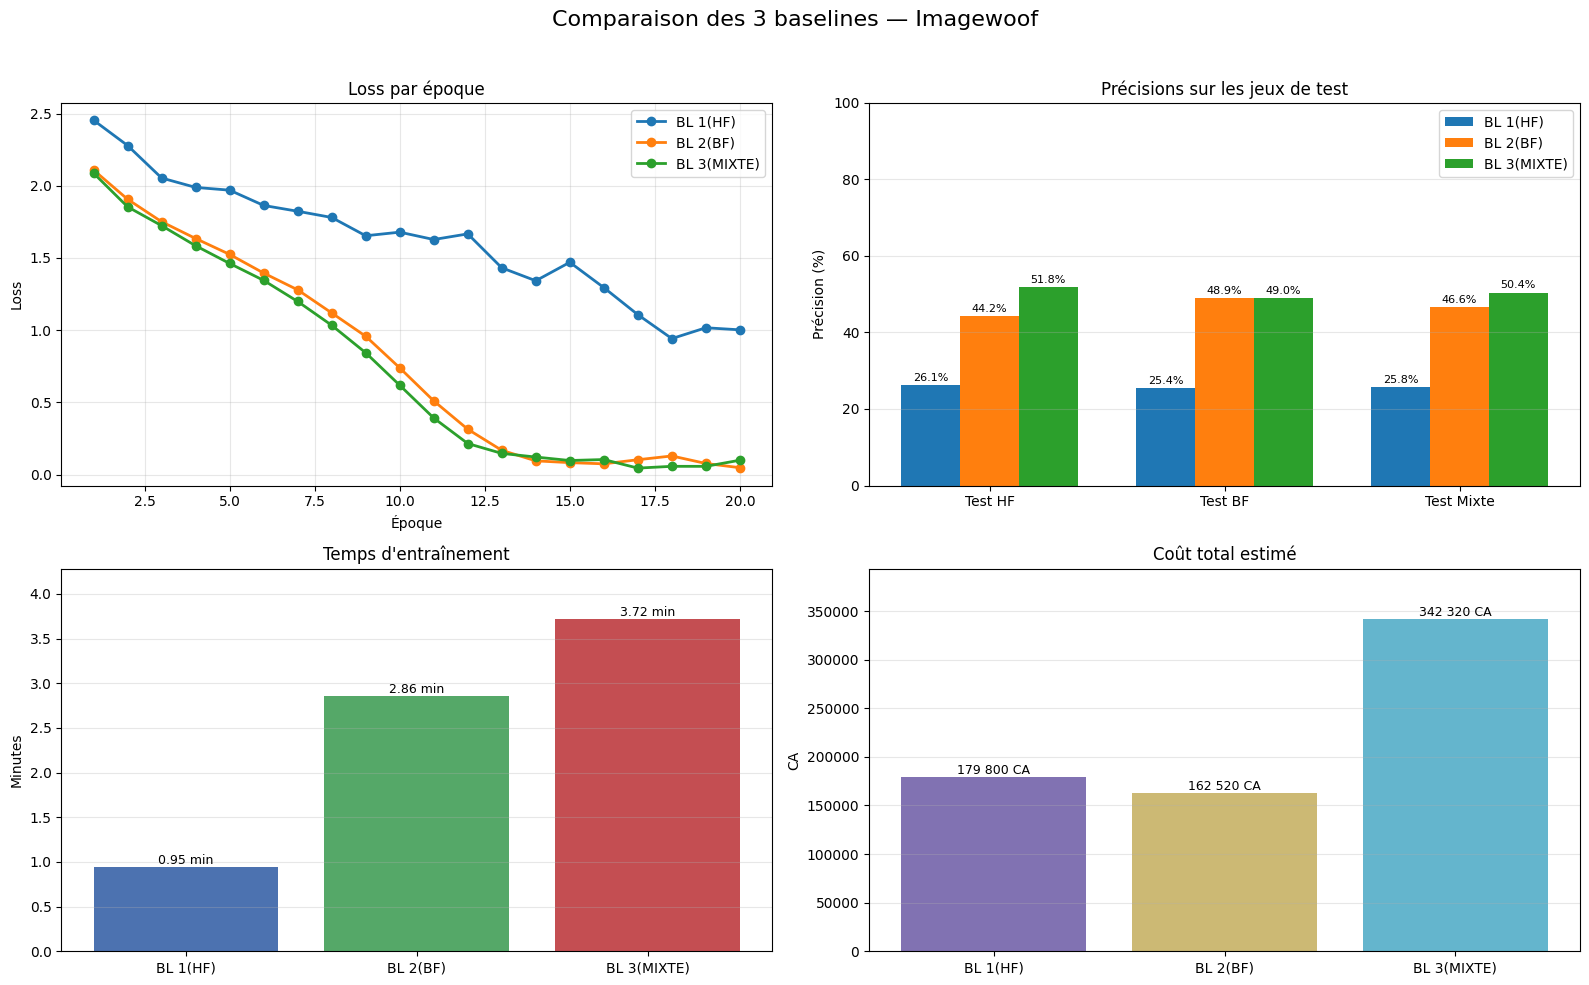


=== RÉCAPITULATIF IMAGEWOOF ===
BL 1(HF)     | HF=26.14%  BF=25.38%  Mixte=25.76%  |  0.95 min  |   179800 CA
BL 2(BF)     | HF=44.21%  BF=48.94%  Mixte=46.58%  |  2.86 min  |   162520 CA
BL 3(MIXTE)  | HF=51.82%  BF=48.97%  Mixte=50.39%  |  3.72 min  |   342320 CA


In [8]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

imagewoof_dir = "/content/drive/MyDrive/UTBM_PF22/results/Imagewoof"

baseline_keys = ["HF", "BF", "MIXTE"]
baseline_labels = {
    "HF":    "BL 1(HF)",
    "BF":    "BL 2(BF)",
    "MIXTE": "BL 3(MIXTE)",
}

# Lecture des JSON produits par train_baselines.py
data = {}
for k in baseline_keys:
    path = os.path.join(imagewoof_dir, f"results_baseline_{k}.json")
    with open(path, "r") as f:
        data[k] = json.load(f)

# Clés exactes écrites par train_baselines.py (version modifiée avec loss_history) :
#   accuracy_HF, accuracy_BF, accuracy_Mixte, total_cost_CA, training_time_sec, loss_history
losses = {k: data[k].get("loss_history", []) for k in baseline_keys}
accuracies = {
    k: [data[k]["accuracy_HF"], data[k]["accuracy_BF"], data[k]["accuracy_Mixte"]]
    for k in baseline_keys
}
train_time_min = {k: data[k]["training_time_sec"] / 60.0 for k in baseline_keys}
cost_total_ca = {k: data[k]["total_cost_CA"] for k in baseline_keys}

acc_labels = ["Test HF", "Test BF", "Test Mixte"]
has_losses = any(len(losses[k]) > 0 for k in baseline_keys)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Comparaison des 3 baselines — Imagewoof", fontsize=16)

# 1) Courbes de loss
ax = axes[0, 0]
if has_losses:
    for k in baseline_keys:
        y = losses[k]
        if len(y) > 0:
            ax.plot(np.arange(1, len(y) + 1), y, marker="o", linewidth=2, label=baseline_labels[k])
    ax.legend()
else:
    ax.text(0.5, 0.5, "loss_history absent du JSON\n(re-run baselines avec la nouvelle version\nde train_baselines.py)",
            ha="center", va="center", transform=ax.transAxes, fontsize=11, color="gray")
ax.set_title("Loss par époque")
ax.set_xlabel("Époque")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3)

# 2) Précisions test (barres groupées)
ax = axes[0, 1]
x = np.arange(len(acc_labels))
width = 0.25
for i, k in enumerate(baseline_keys):
    vals = accuracies[k]
    bars = ax.bar(x + (i - 1) * width, vals, width=width, label=baseline_labels[k])
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.6, f"{h:.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_title("Précisions sur les jeux de test")
ax.set_xticks(x)
ax.set_xticklabels(acc_labels)
ax.set_ylabel("Précision (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend()

# 3) Temps d'entraînement total
ax = axes[1, 0]
time_vals = [train_time_min[k] for k in baseline_keys]
bars = ax.bar([baseline_labels[k] for k in baseline_keys], time_vals, color=["#4C72B0", "#55A868", "#C44E52"])
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.2f} min", ha="center", va="bottom", fontsize=9)
ax.set_title("Temps d'entraînement")
ax.set_ylabel("Minutes")
ax.set_ylim(0, max(time_vals) * 1.15 if max(time_vals) > 0 else 1)
ax.grid(axis="y", alpha=0.3)

# 4) Coût total estimé
ax = axes[1, 1]
cost_vals = [cost_total_ca[k] for k in baseline_keys]
bars = ax.bar([baseline_labels[k] for k in baseline_keys], cost_vals, color=["#8172B2", "#CCB974", "#64B5CD"])
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h, f"{int(h):,} CA".replace(",", " "), ha="center", va="bottom", fontsize=9)
ax.set_title("Coût total estimé")
ax.set_ylabel("CA")
ax.set_ylim(0, max(cost_vals) * 1.15 if max(cost_vals) > 0 else 1)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- Récap textuel ---
print("\n=== RÉCAPITULATIF IMAGEWOOF ===")
for k in baseline_keys:
    print(f"{baseline_labels[k]:<12} | HF={accuracies[k][0]:5.2f}%  BF={accuracies[k][1]:5.2f}%  Mixte={accuracies[k][2]:5.2f}%  | {train_time_min[k]:5.2f} min  | {cost_total_ca[k]:>8} CA")